In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report
from lightgbm import LGBMClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
import joblib

In [2]:
ai_generated_text = pd.read_csv('ai_essays.csv')
human_essays = pd.read_csv('human_essays.csv')

In [3]:
print(ai_generated_text.head())
print(human_essays.head())

                                                text  generated
0  The healthcare industry is experiencing a para...          1
1  AI is playing a crucial role in advancing scie...          1
2  In the era of digital transformation, Artifici...          1
3  In the era of digital transformation, Artifici...          1
4  The future of AI is full of possibilities, wit...          1
                                                text  generated
0  Do curfews keep teenagers from Getting into tr...        0.0
1  In this article "The Challenge of Exploring Ve...        0.0
2  With THP rapid growth of THP Internet in recen...        0.0
3  The electoral College is the way Us United Sta...        0.0
4  This technology of you can calculate the emoti...        0.0


In [4]:
ai_generated_text.shape


(10000, 2)

In [5]:
human_essays.shape

(10000, 2)

In [6]:
# Combine the datasets
combined_data = pd.concat([ai_generated_text, human_essays], axis=0).reset_index(drop=True)

# Shuffle the combined dataset
combined_data = combined_data.sample(frac=1).reset_index(drop=True)

In [7]:
# Preprocessing function
def preprocess_text(text):
    # Convert to lowercase
    text = text.str.lower()
    # Remove punctuation
    text = text.str.replace('[^\w\s]', '', regex=True)
    # Remove numbers
    text = text.str.replace('\d+', '', regex=True)
    return text

In [8]:
# Apply the preprocessing
combined_data['text'] = preprocess_text(combined_data['text'])

In [9]:
# Feature Extraction using TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(combined_data['text']).toarray()
y = combined_data['generated']

In [10]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [11]:
# Save the TF-IDF vectorizer
tfidf_filename = "tfidf_vectorizer.joblib"
joblib.dump(tfidf, tfidf_filename)
print(f"TF-IDF vectorizer saved as {tfidf_filename}")

TF-IDF vectorizer saved as tfidf_vectorizer.joblib


In [12]:
from sklearn.svm import SVC
# Define the models
models = {
    "LightGBM": LGBMClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": MultinomialNB(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": xgb.XGBClassifier(),
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "Multilayer Perceptron": MLPClassifier(max_iter=300),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}


In [13]:
# Train, evaluate, and save the models
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))
    print("\n")
    
    # Save the trained model to a file
    model_filename = f"{name.replace(' ', '_').lower()}_model.joblib"
    joblib.dump(model, model_filename)
    print(f"{name} model saved as {model_filename}\n")

Training LightGBM...


/Users/srihari/Documents/Desertation/Final/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 7999, number of negative: 8001
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.177696 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 281548
[LightGBM] [Info] Number of data points in the train set: 16000, number of used features: 4631
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499937 -> initscore=-0.000250
[LightGBM] [Info] Start training from score -0.000250
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

/Users/srihari/Documents/Desertation/Final/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Decision Tree Accuracy: 0.9998
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1999
         1.0       1.00      1.00      1.00      2001

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



Decision Tree model saved as decision_tree_model.joblib

Training Naive Bayes...
Naive Bayes Accuracy: 1.0000
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1999
         1.0       1.00      1.00      1.00      2001

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



Naive Bayes model saved as naive_bayes_model.joblib

Training Gradient Boosting...
Gradient Boosting Accuracy: 1.0000
              precision    recall  f1-score   support

         0.0       1.00     

# Testing on Kaggle data, Unbalanced

In [15]:
import os
import pandas as pd
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report

# Preprocessing function
def preprocess_text(text):
    # Convert to lowercase
    text = text.str.lower()
    # Remove punctuation
    text = text.str.replace('[^\w\s]', '', regex=True)
    # Remove numbers
    text = text.str.replace('\d+', '', regex=True)
    return text

# Step 1: Load the new dataset
new_data = pd.read_csv('AI_Human.csv')

# Step 2: Handle missing values
# Drop rows where 'text' is NaN or empty
new_data = new_data.dropna(subset=['text'])

# Preprocess the text data
new_data['text'] = preprocess_text(new_data['text'])

# Step 3: Apply the same TF-IDF Vectorizer used in training
tfidf_vectorizer = joblib.load('tfidf_vectorizer.joblib')

# Transform the text data in the new dataset
X_new = tfidf_vectorizer.transform(new_data['text'])

# Convert sparse matrix to dense(For SVM Model)
X_new_dense = X_new.toarray()

# If the 'generated' label exists in the new dataset, extract it
if 'generated' in new_data.columns:
    y_new = new_data['generated']
    # Remove rows where 'generated' is NaN
    y_new = y_new.dropna()

In [16]:
# Step 4: Load the trained models and evaluate them on the new dataset
model_names = ['svm_model.joblib', 'decision_tree_model.joblib', 'naive_bayes_model.joblib', 
               'xgboost_model.joblib', 'random_forest_model.joblib', 'lightgbm_model.joblib', 
               'multilayer_perceptron_model.joblib', 'gradient_boosting_model.joblib', 
               'knn_model.joblib']

for model_name in model_names:
    # Construct the path to the model file
    model_path = os.path.join('joblib_files', model_name)
    
    # Load the model
    model = joblib.load(model_path)
    
    # Check if the model is an SVM or similar model that requires dense input
    if model_name == 'svm_model.joblib':
        y_pred_new = model.predict(X_new_dense)
    else:
        y_pred_new = model.predict(X_new)
    
    # If labels are available, evaluate the model
    if 'generated' in new_data.columns:
        # Remove corresponding entries in y_pred_new where y_new had NaNs
        y_pred_new = y_pred_new[y_new.index]
        
        accuracy = accuracy_score(y_new, y_pred_new)
        report = classification_report(y_new, y_pred_new)
        print(f"{model_name} Accuracy on new dataset: {accuracy:.4f}")
        print(f"Classification Report:\n{report}\n")
    else:
        # If labels are not available, just show predictions
        print(f"Predictions by {model_name}:\n{y_pred_new}\n") 

svm_model.joblib Accuracy on new dataset: 0.6178
Classification Report:
              precision    recall  f1-score   support

         0.0       0.62      1.00      0.76    207779
         1.0       1.00      0.00      0.00    128536

    accuracy                           0.62    336315
   macro avg       0.81      0.50      0.38    336315
weighted avg       0.76      0.62      0.47    336315


decision_tree_model.joblib Accuracy on new dataset: 0.6310
Classification Report:
              precision    recall  f1-score   support

         0.0       0.63      1.00      0.77    207779
         1.0       0.97      0.04      0.07    128536

    accuracy                           0.63    336315
   macro avg       0.80      0.52      0.42    336315
weighted avg       0.76      0.63      0.50    336315


naive_bayes_model.joblib Accuracy on new dataset: 0.6183
Classification Report:
              precision    recall  f1-score   support

         0.0       0.62      1.00      0.76    207779
 

/Users/srihari/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [15:25:43] WARNING: /Users/runner/work/xgboost/xgboost/src/gbm/../common/error_msg.h:80: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  warnings.warn(smsg, UserWarning)


xgboost_model.joblib Accuracy on new dataset: 0.6288
Classification Report:
              precision    recall  f1-score   support

         0.0       0.62      1.00      0.77    207779
         1.0       0.98      0.03      0.06    128536

    accuracy                           0.63    336315
   macro avg       0.80      0.51      0.41    336315
weighted avg       0.76      0.63      0.50    336315


random_forest_model.joblib Accuracy on new dataset: 0.6179
Classification Report:
              precision    recall  f1-score   support

         0.0       0.62      1.00      0.76    207779
         1.0       1.00      0.00      0.00    128536

    accuracy                           0.62    336315
   macro avg       0.81      0.50      0.38    336315
weighted avg       0.76      0.62      0.47    336315


lightgbm_model.joblib Accuracy on new dataset: 0.6291
Classification Report:
              precision    recall  f1-score   support

         0.0       0.62      1.00      0.77    207779


# Visualisations

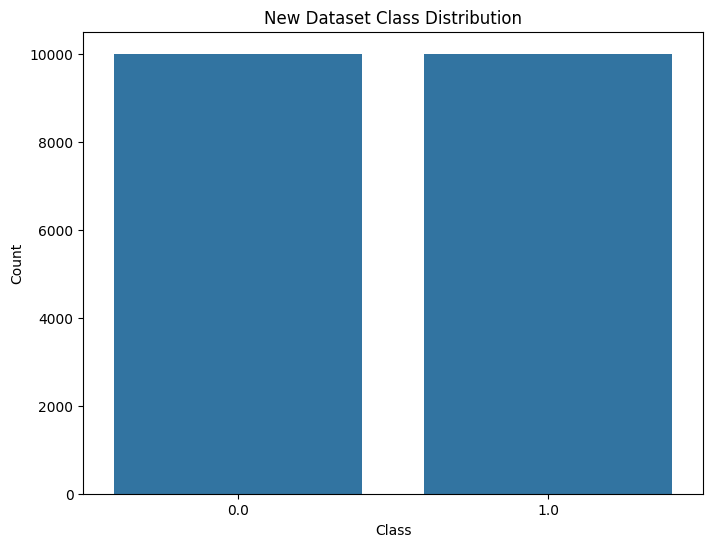

In [17]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.inspection import permutation_importance

# 1. Class Distribution Visualization
def plot_class_distribution(data, title='Class Distribution'):
    plt.figure(figsize=(8, 6))
    sns.countplot(x='generated', data=data)
    plt.title(title)
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.show()

# Original dataset class distribution
plot_class_distribution(combined_data, 'New Dataset Class Distribution')

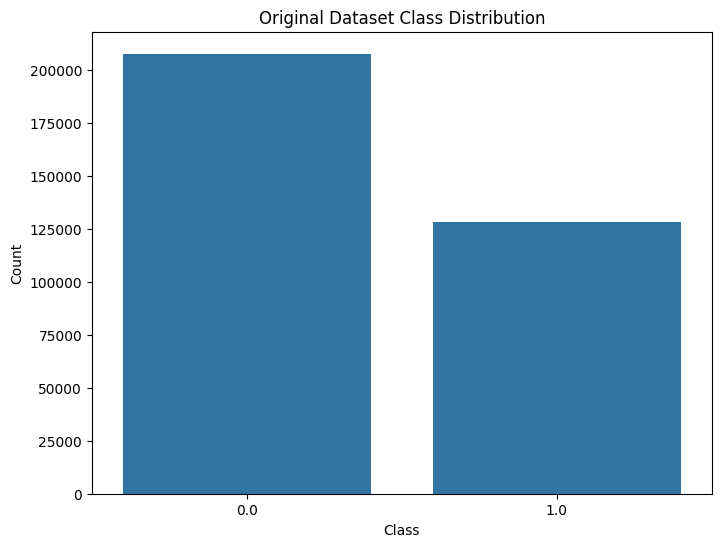

In [18]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.inspection import permutation_importance

# 1. Class Distribution Visualization
def plot_class_distribution(data, title='Class Distribution'):
    plt.figure(figsize=(8, 6))
    sns.countplot(x='generated', data=data)
    plt.title(title)
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.show()

# Original dataset class distribution
plot_class_distribution(new_data, 'Original Dataset Class Distribution')

/var/folders/s4/p8_vw_mn597b28z01m8yjwpw0000gn/T/ipykernel_32266/4010810483.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=df_results, palette='viridis')


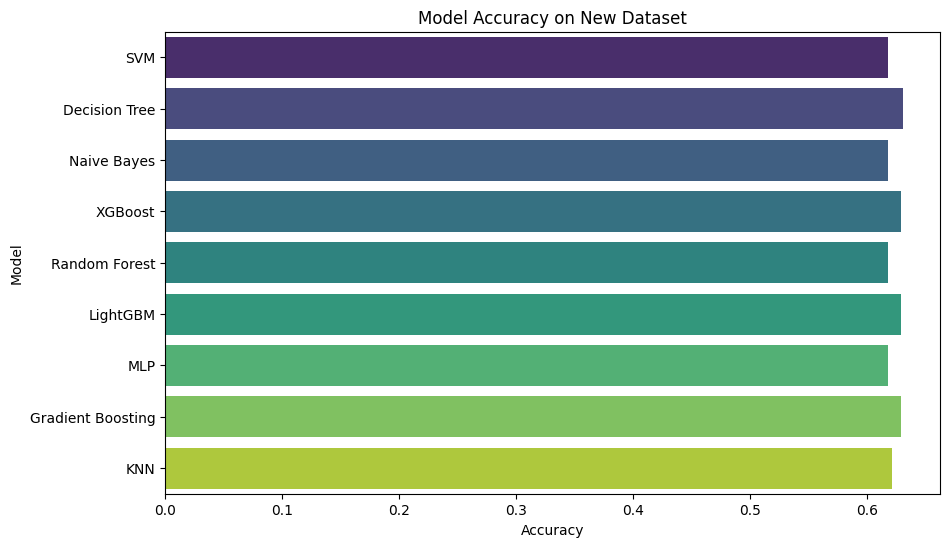

/var/folders/s4/p8_vw_mn597b28z01m8yjwpw0000gn/T/ipykernel_32266/4010810483.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric, y='Model', data=df_results, palette='coolwarm')
/var/folders/s4/p8_vw_mn597b28z01m8yjwpw0000gn/T/ipykernel_32266/4010810483.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric, y='Model', data=df_results, palette='coolwarm')
/var/folders/s4/p8_vw_mn597b28z01m8yjwpw0000gn/T/ipykernel_32266/4010810483.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric, y='Model', data=df_results, palett

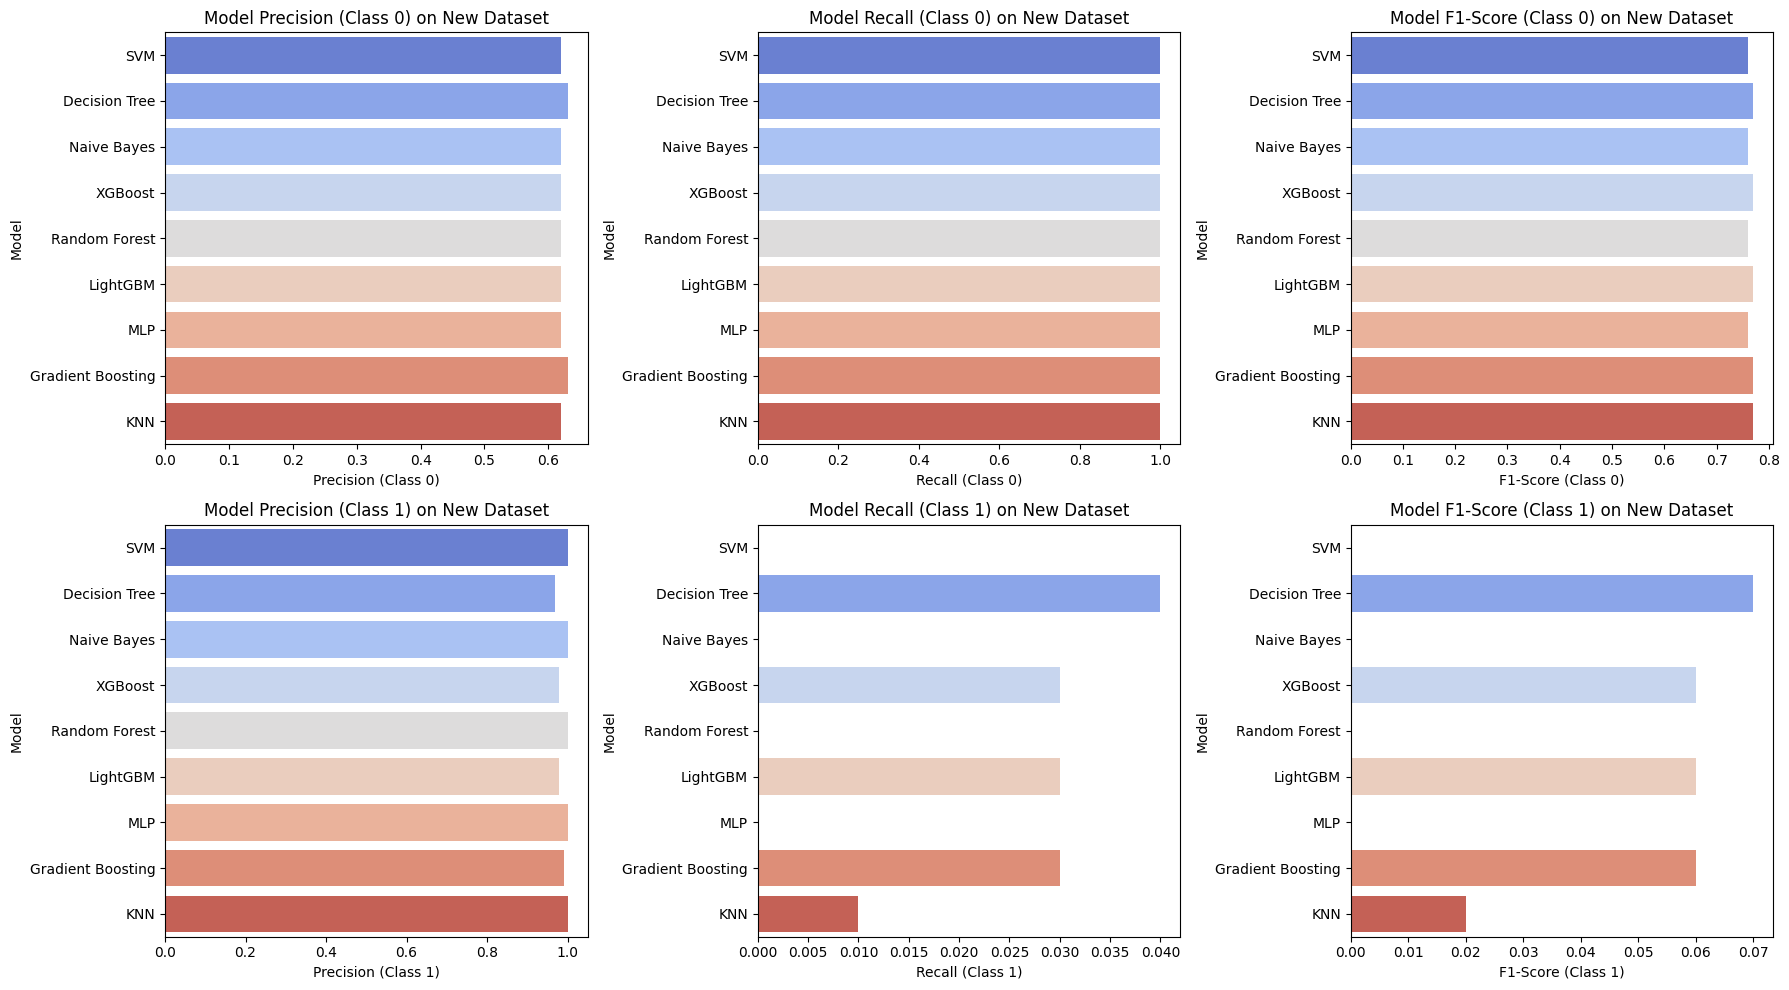

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Given model results
model_results = {
    'Model': ['SVM', 'Decision Tree', 'Naive Bayes', 'XGBoost', 'Random Forest', 
              'LightGBM', 'MLP', 'Gradient Boosting', 'KNN'],
    'Accuracy': [0.6178, 0.6310, 0.6183, 0.6288, 0.6179, 0.6291, 0.6182, 0.6296, 0.6219],
    'Precision_Class_0': [0.62, 0.63, 0.62, 0.62, 0.62, 0.62, 0.62, 0.63, 0.62],
    'Recall_Class_0': [1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00],
    'F1_Class_0': [0.76, 0.77, 0.76, 0.77, 0.76, 0.77, 0.76, 0.77, 0.77],
    'Precision_Class_1': [1.00, 0.97, 1.00, 0.98, 1.00, 0.98, 1.00, 0.99, 1.00],
    'Recall_Class_1': [0.00, 0.04, 0.00, 0.03, 0.00, 0.03, 0.00, 0.03, 0.01],
    'F1_Class_1': [0.00, 0.07, 0.00, 0.06, 0.00, 0.06, 0.00, 0.06, 0.02]
}

df_results = pd.DataFrame(model_results)

# 1. Bar Plot for Accuracy
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=df_results, palette='viridis')
plt.title('Model Accuracy on New Dataset')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.show()

# 2. Bar Plots for Precision, Recall, and F1-Score for each class
metrics = ['Precision_Class_0', 'Recall_Class_0', 'F1_Class_0', 'Precision_Class_1', 'Recall_Class_1', 'F1_Class_1']
metric_titles = ['Precision (Class 0)', 'Recall (Class 0)', 'F1-Score (Class 0)', 
                 'Precision (Class 1)', 'Recall (Class 1)', 'F1-Score (Class 1)']

plt.figure(figsize=(18, 10))
for i, metric in enumerate(metrics):
    plt.subplot(2, 3, i + 1)
    sns.barplot(x=metric, y='Model', data=df_results, palette='coolwarm')
    plt.title(f'Model {metric_titles[i]} on New Dataset')
    plt.xlabel(metric_titles[i])
    plt.ylabel('Model')

plt.tight_layout()
plt.show()

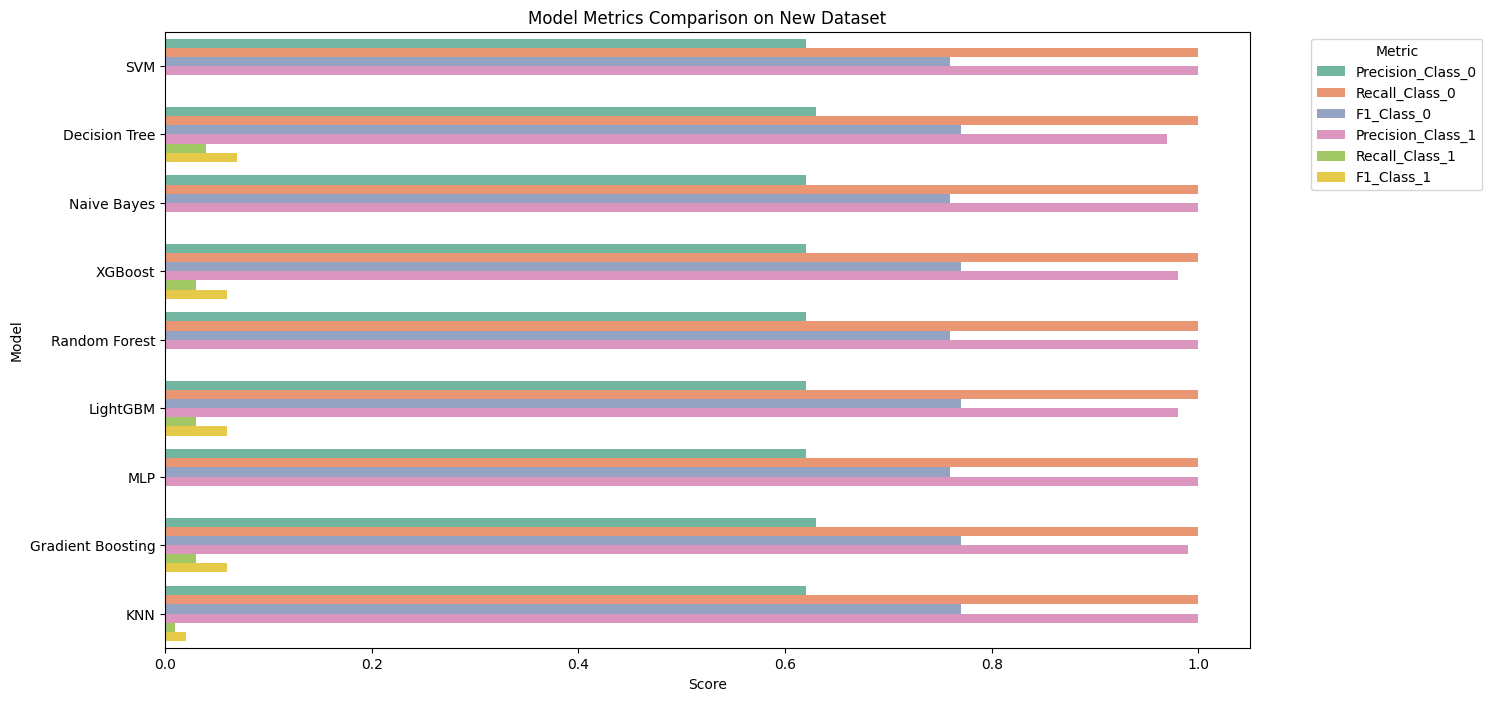

In [2]:
# 3. Combined Metrics Visualization for each class
# Prepare data for combined visualization
df_long = pd.melt(df_results, id_vars=['Model'], 
                  value_vars=['Precision_Class_0', 'Recall_Class_0', 'F1_Class_0', 
                              'Precision_Class_1', 'Recall_Class_1', 'F1_Class_1'],
                  var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 8))
sns.barplot(x='Score', y='Model', hue='Metric', data=df_long, palette='Set2')
plt.title('Model Metrics Comparison on New Dataset')
plt.xlabel('Score')
plt.ylabel('Model')
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

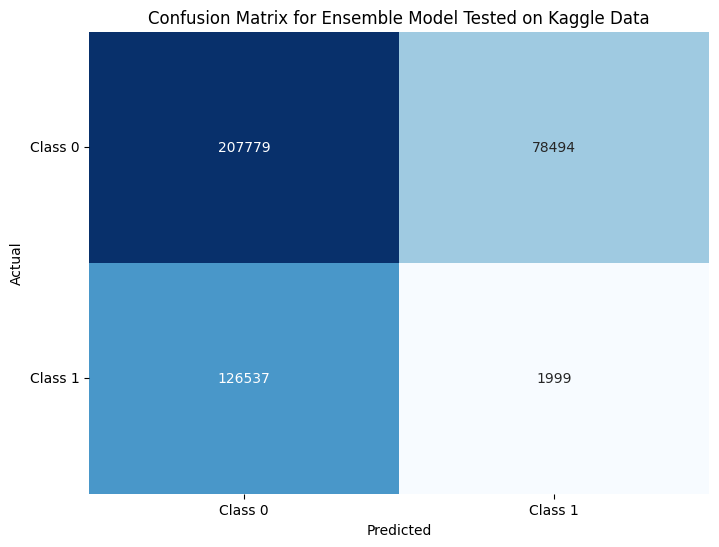

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Given support values
support_0 = 207779  # Number of actual instances of Class 0
support_1 = 128536  # Number of actual instances of Class 1

# Calculate the average recall and precision across all models
avg_recall_0 = np.mean([1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00])
avg_recall_1 = np.mean([0.00, 0.04, 0.00, 0.03, 0.00, 0.03, 0.00, 0.03, 0.01])
avg_precision_0 = np.mean([0.62, 0.63, 0.62, 0.62, 0.62, 0.62, 0.62, 0.63, 0.62])
avg_precision_1 = np.mean([1.00, 0.97, 1.00, 0.98, 1.00, 0.98, 1.00, 0.99, 1.00])

# Calculate the collective confusion matrix
# True Negatives (TN) for Class 0 (correctly predicted negatives)
TN = avg_recall_0 * support_0

# False Positives (FP) for Class 0 (incorrectly predicted positives)
FP = (1 - avg_precision_0) * (avg_recall_0 * support_0 + (1 - avg_recall_0) * support_1)

# False Negatives (FN) for Class 1 (incorrectly predicted negatives)
FN = (1 - avg_recall_1) * support_1

# True Positives (TP) for Class 1 (correctly predicted positives)
TP = avg_recall_1 * support_1

# Confusion matrix
cm = np.array([[TN, FP], [FN, TP]])

# Plotting the confusion matrix
def plot_confusion_matrix(cm, model_name):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix for Ensemble Model Tested on Kaggle Data')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks([0.5, 1.5], ['Class 0', 'Class 1'], rotation=0)
    plt.yticks([0.5, 1.5], ['Class 0', 'Class 1'], rotation=0)
    plt.show()

plot_confusion_matrix(cm, 'All Models')


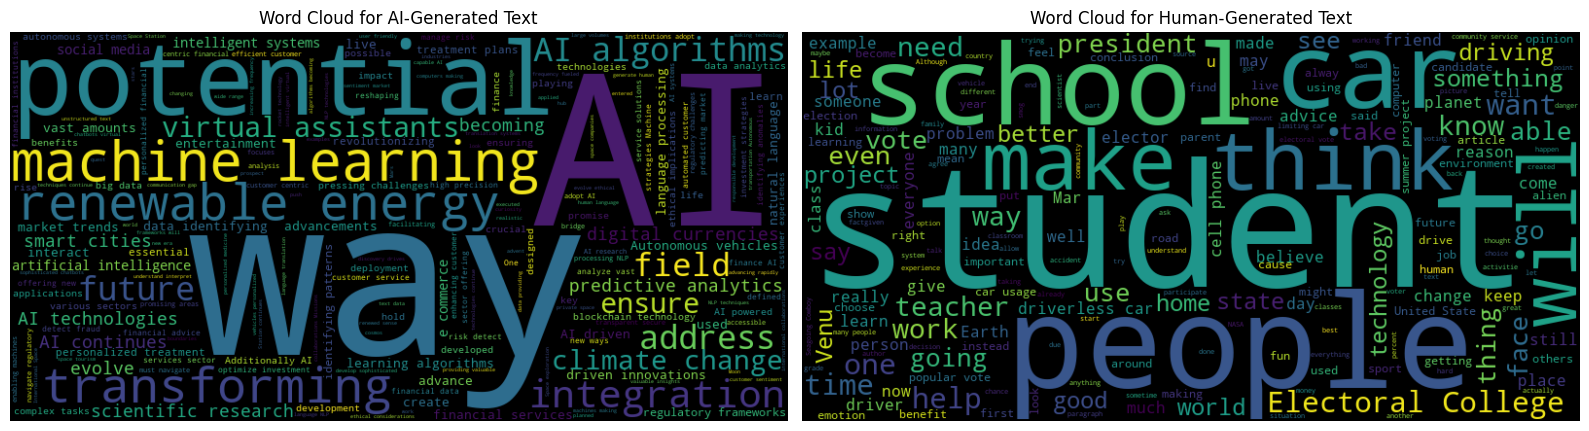

In [9]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt


# Step 1: Load Your Data
# Replace 'your_data_file.csv' with the path to your data file
# Replace 'text_column' and 'generated_column' with the actual column names in your dataset
data = combined_data
text_column = 'text'  # Column containing the text data
generated_column = 'generated'  # Column indicating if text is AI-generated (1) or Human-generated (0)

# Step 2: Filter the Data
# AI-generated text
ai_generated_text = ' '.join(data[data[generated_column] == 1][text_column].dropna().astype(str))

# Human-generated text
human_generated_text = ' '.join(data[data[generated_column] == 0][text_column].dropna().astype(str))

# Step 3: Generate Word Clouds
wordcloud_ai = WordCloud(width=800, height=400, background_color='black', 
                         colormap='viridis', max_words=200, 
                         contour_width=3, contour_color='white').generate(ai_generated_text)

wordcloud_human = WordCloud(width=800, height=400, background_color='black', 
                            colormap='viridis', max_words=200, 
                            contour_width=3, contour_color='white').generate(human_generated_text)

# Step 4: Plot Word Clouds Side by Side
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(wordcloud_ai, interpolation='bilinear')
plt.title('Word Cloud for AI-Generated Text')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_human, interpolation='bilinear')
plt.title('Word Cloud for Human-Generated Text')
plt.axis('off')

plt.tight_layout()
plt.show()


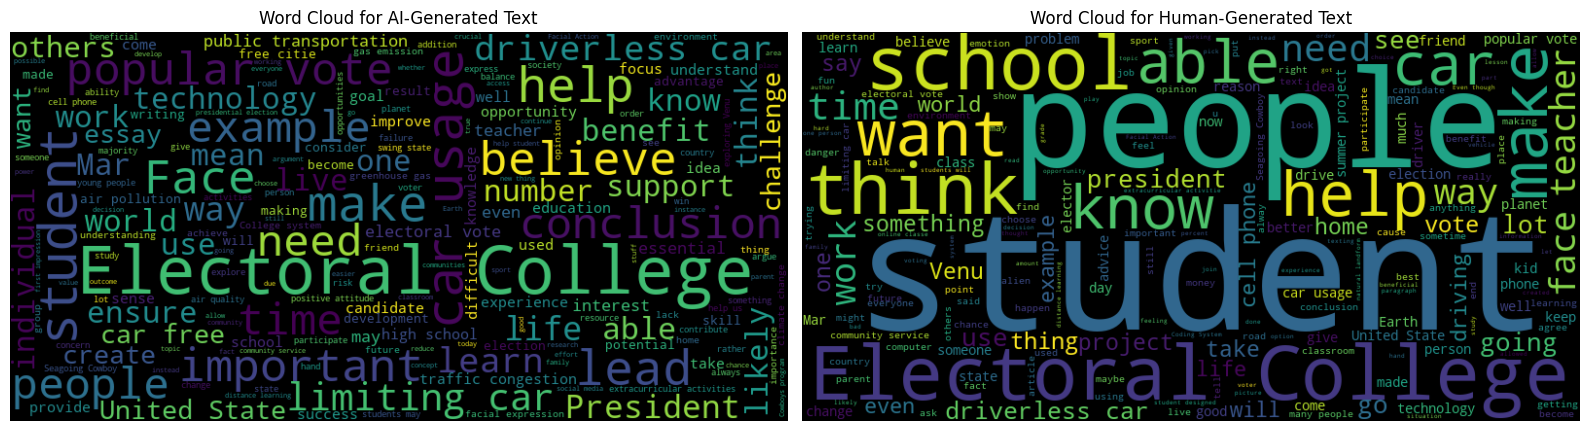

In [11]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt


# Load Your Data
# Replace 'your_data_file.csv' with the path to your data file
# Replace 'text_column' and 'generated_column' with the actual column names in your dataset
data = pd.read_csv('AI_Human.csv')

text_column = 'text'  # Column containing the text data
generated_column = 'generated'  # Column indicating if text is AI-generated (1) or Human-generated (0)

#  Filter the Data
# AI-generated text
ai_generated_text = ' '.join(data[data[generated_column] == 1][text_column].dropna().astype(str))

# Human-generated text
human_generated_text = ' '.join(data[data[generated_column] == 0][text_column].dropna().astype(str))

# Generate Word Clouds
wordcloud_ai = WordCloud(width=800, height=400, background_color='black', 
                         colormap='viridis', max_words=200, 
                         contour_width=3, contour_color='white').generate(ai_generated_text)

wordcloud_human = WordCloud(width=800, height=400, background_color='black', 
                            colormap='viridis', max_words=200, 
                            contour_width=3, contour_color='white').generate(human_generated_text)

# Plot Word Clouds Side by Side
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(wordcloud_ai, interpolation='bilinear')
plt.title('Word Cloud for AI-Generated Text')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_human, interpolation='bilinear')
plt.title('Word Cloud for Human-Generated Text')
plt.axis('off')

plt.tight_layout()
plt.show()


# Hyper parameter tuning

In [34]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.neural_network import MLPClassifier
import joblib

# Define the hyperparameters grid for each model
param_grid_svm = {
    'clf__C': [0.1, 1, 10],
    'clf__kernel': ['linear', 'rbf']
}

param_grid_dt = {
    'clf__max_depth': [10, 20, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
}

param_grid_nb = {
    # Naive Bayes has no hyperparameters to tune, so we can keep this simple
}

param_grid_knn = {
    'clf__n_neighbors': [3, 5, 7],
    'clf__weights': ['uniform', 'distance'],
    'clf__metric': ['euclidean', 'manhattan']
}

param_grid_rf = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [10, 20, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
}

param_grid_gb = {
    'clf__n_estimators': [100, 200],
    'clf__learning_rate': [0.01, 0.1, 0.5],
    'clf__max_depth': [3, 4, 5],
}

param_grid_xgb = {
    'clf__n_estimators': [100, 200],
    'clf__learning_rate': [0.01, 0.1, 0.5],
    'clf__max_depth': [3, 4, 5],
}

param_grid_lgbm = {
    'clf__n_estimators': [100, 200],
    'clf__learning_rate': [0.01, 0.1, 0.5],
    'clf__max_depth': [-1, 10, 20],
}

param_grid_mlp = {
    'clf__hidden_layer_sizes': [(100,), (50, 50), (30, 30, 30)],
    'clf__activation': ['relu', 'tanh'],
    'clf__learning_rate_init': [0.001, 0.01, 0.1]
}

In [35]:
# Define pipelines for each model
pipelines = {
    'svm': Pipeline([('pca', PCA(n_components=50)), ('clf', SVC(probability=True))]),
    'dt': Pipeline([('pca', PCA(n_components=50)), ('clf', DecisionTreeClassifier())]),
    'nb': Pipeline([('pca', PCA(n_components=50)), ('clf', GaussianNB())]),
    'knn': Pipeline([('pca', PCA(n_components=50)), ('clf', KNeighborsClassifier())]),
    'rf': Pipeline([('pca', PCA(n_components=50)), ('clf', RandomForestClassifier())]),
    'gb': Pipeline([('pca', PCA(n_components=50)), ('clf', GradientBoostingClassifier())]),
    'xgb': Pipeline([('pca', PCA(n_components=50)), ('clf', xgb.XGBClassifier())]),
    'lgbm': Pipeline([('pca', PCA(n_components=50)), ('clf', lgb.LGBMClassifier())]),
    'mlp': Pipeline([('pca', PCA(n_components=50)), ('clf', MLPClassifier(max_iter=500))]),
}

# Define parameter grids for each model
param_grids = {
    'svm': param_grid_svm,
    'dt': param_grid_dt,
    'nb': param_grid_nb,
    'knn': param_grid_knn,
    'rf': param_grid_rf,
    'gb': param_grid_gb,
    'xgb': param_grid_xgb,
    'lgbm': param_grid_lgbm,
    'mlp': param_grid_mlp,
}

# Testing on the kaggle data after hyperparameter tuning: Unbalanced

In [38]:
# Step 4: Load the trained models and evaluate them on the new dataset
model_names = ['ensemble_model.joblib']

for model_name in model_names:
    # Construct the path to the model file
    model_path = os.path.join(model_name)
    
    # Load the model
    model = joblib.load(model_path)
    y_pred_new = model.predict(X_new)
    
    # If labels are available, evaluate the model
    if 'generated' in new_data.columns:
        # Remove corresponding entries in y_pred_new where y_new had NaNs
        y_pred_new = y_pred_new[y_new.index]
        
        accuracy = accuracy_score(y_new, y_pred_new)
        report = classification_report(y_new, y_pred_new)
        print(f"{model_name} Accuracy on new dataset: {accuracy:.4f}")
        print(f"Classification Report:\n{report}\n")
    else:
        # If labels are not available, just show predictions
        print(f"Predictions by {model_name}:\n{y_pred_new}\n")

ensemble_model.joblib Accuracy on new dataset: 0.6189
Classification Report:
              precision    recall  f1-score   support

         0.0       0.62      1.00      0.76    207779
         1.0       1.00      0.00      0.01    128536

    accuracy                           0.62    336315
   macro avg       0.81      0.50      0.39    336315
weighted avg       0.76      0.62      0.47    336315




# Testing the kaggle data by balancing(Reducing the mejority class)

In [1]:
import os
import pandas as pd
import joblib
from sklearn.utils import resample
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report

# Preprocessing function
def preprocess_text(text):
    # Convert to lowercase
    text = text.str.lower()
    # Remove punctuation
    text = text.str.replace('[^\w\s]', '', regex=True)
    # Remove numbers
    text = text.str.replace('\d+', '', regex=True)
    return text

In [2]:
# Step 1: Load the new dataset
new_data = pd.read_csv('AI_Human.csv')
# Use a smaller sample of the dataset to reduce memory usage
new_data_sample = new_data.sample(frac=0.1, random_state=42)

# Step 2: Handle missing values
# Drop rows where 'text' is NaN or empty
new_data_sample = new_data_sample.dropna(subset=['text'])
# Preprocess the text data
new_data_sample['text'] = preprocess_text(new_data_sample['text'])

# Step 3: Apply the same TF-IDF Vectorizer used in training
# Load the vectorizer used during training
tfidf_vectorizer = joblib.load('tfidf_vectorizer.joblib')
# Transform the text data in the new dataset
X_new = tfidf_vectorizer.transform(new_data_sample['text'])

In [3]:
# If the 'generated' label exists in the new dataset, extract it
if 'generated' in new_data_sample.columns:
    y_new = new_data_sample['generated']
    
    # Remove rows where 'generated' is NaN
    y_new = y_new.dropna()
    # Ensure that X_new and y_new have aligned indices
    y_new = y_new.reset_index(drop=True)
    X_new = X_new[y_new.index, :]
    # Convert y_new to a DataFrame for easier manipulation
    y_new_df = pd.DataFrame({'generated': y_new.values})
    
    # Step 4: Resample the new dataset to create a balanced dataset
    # Separate the majority and minority classes
    majority_class_indices = y_new_df[y_new_df['generated'] == 0].index
    minority_class_indices = y_new_df[y_new_df['generated'] == 1].index
    
    # Determine the size of the minority class
    minority_size = len(minority_class_indices)
    
    # Randomly undersample the majority class indices
    majority_class_undersampled_indices = resample(majority_class_indices,
                                                   replace=False,
                                                   n_samples=minority_size,
                                                   random_state=42)
    
    # Combine the undersampled majority class indices with the minority class indices
    balanced_indices = majority_class_undersampled_indices.tolist() + minority_class_indices.tolist()
    
    # Subset X_new and y_new to create balanced datasets
    X_new_balanced_sparse = X_new[balanced_indices, :]
    y_new_balanced = y_new_df.loc[balanced_indices, 'generated'].reset_index(drop=True)


In [4]:
# Step 5: Evaluate the model(s) on the balanced dataset
model_names = ['ensemble_model.joblib']
for model_name in model_names:
    # Load the model
    model = joblib.load(model_name)
    
    # Predict on the balanced dataset
    y_pred_new = model.predict(X_new_balanced_sparse)
    
    # Evaluate the model
    accuracy = accuracy_score(y_new_balanced, y_pred_new)
    report = classification_report(y_new_balanced, y_pred_new)
    
    # Print the results
    print(f"{model_name} Accuracy on balanced dataset: {accuracy:.4f}")
    print(f"Classification Report:\n{report}\n")

/Users/srihari/anaconda3/lib/python3.11/site-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


ensemble_model.joblib Accuracy on balanced dataset: 0.5014
Classification Report:
              precision    recall  f1-score   support

         0.0       0.50      1.00      0.67     12797
         1.0       1.00      0.00      0.01     12797

    accuracy                           0.50     25594
   macro avg       0.75      0.50      0.34     25594
weighted avg       0.75      0.50      0.34     25594




In [5]:
# Step 4: Load the trained models and evaluate them on the new dataset
model_names = ['lightgbm_model.joblib', 'multilayer_perceptron_model.joblib', 'gradient_boosting_model.joblib', 
               'knn_model.joblib', 'svm_model.joblib', 'decision_tree_model.joblib', 'naive_bayes_model.joblib', 
               'xgboost_model.joblib', 'random_forest_model.joblib']

for model_name in model_names:
    # Construct the path to the model file
    model_path = os.path.join(model_name)
    
    # Load the model
    model = joblib.load(model_path)
    y_pred_new = model.predict(X_new)
    
    # If labels are available, evaluate the model
    if 'generated' in new_data.columns:
        # Remove corresponding entries in y_pred_new where y_new had NaNs
        y_pred_new = y_pred_new[y_new.index]
        
        accuracy = accuracy_score(y_new, y_pred_new)
        report = classification_report(y_new, y_pred_new)
        print(f"{model_name} Accuracy on new dataset: {accuracy:.4f}")
        print(f"Classification Report:\n{report}\n")
    else:
        # If labels are not available, just show predictions
        print(f"Predictions by {model_name}:\n{y_pred_new}\n")

lightgbm_model.joblib Accuracy on new dataset: 0.6314
Classification Report:
              precision    recall  f1-score   support

         0.0       0.63      1.00      0.77     20835
         1.0       0.98      0.03      0.06     12797

    accuracy                           0.63     33632
   macro avg       0.80      0.52      0.42     33632
weighted avg       0.76      0.63      0.50     33632


multilayer_perceptron_model.joblib Accuracy on new dataset: 0.6200
Classification Report:
              precision    recall  f1-score   support

         0.0       0.62      1.00      0.77     20835
         1.0       1.00      0.00      0.00     12797

    accuracy                           0.62     33632
   macro avg       0.81      0.50      0.38     33632
weighted avg       0.76      0.62      0.48     33632


gradient_boosting_model.joblib Accuracy on new dataset: 0.6315
Classification Report:
              precision    recall  f1-score   support

         0.0       0.63      1.00   

ValueError: cannot use sparse input in 'SVC' trained on dense data

In [2]:
import pandas as pd

# Create the dataset based on the specified fields
data = {
    "Packing Number": [101, 102, 103, 104, 105],
    "Packing Date": ["2024-09-01", "2024-09-02", "2024-09-03", "2024-09-04", "2024-09-05"],
    "SO Number": ["SO1001", "SO1002", "SO1003", "SO1004", "SO1005"],
    "Notes": ["First batch", "Urgent", "Check quality", "Customer request", "Standard"],
    "Quantity Packed": [50, 75, 60, 80, 90],
    "Item Name": ["Kombucha - Original", "Kombucha - Ginger", "Kombucha - Lemon", "Kombucha - Hibiscus", "Kombucha - Mixed Berry"]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Save the dataset to an Excel file
output_path = 'Oichi_Packing_Data.xlsx'
df.to_excel(output_path, index=False)

output_path

'Oichi_Packing_Data.xlsx'

In [2]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.
